# EDA анализ датасета

**План**
1. Загрузка данных
2. Анализ структуры
3. Пропуски
4. Дубли
5. Аномалии
6. Временные данные
7. Решения

## 1. Загрузка


In [1]:
import glob
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
files = sorted(glob.glob('../data/raw/*.csv'))

dfs = []
for file_name in files:
    small_df = pd.read_csv(file_name)
    small_df['source_file'] = os.path.basename(file_name)
    print(f'{file_name}: {len(small_df):,} строк')
    dfs.append(small_df)

df = pd.concat(dfs, ignore_index=True)
del dfs
df

../data/raw\2019-Dec.csv: 3,533,286 строк
../data/raw\2019-Nov.csv: 4,635,837 строк
../data/raw\2019-Oct.csv: 4,102,283 строк
../data/raw\2020-Feb.csv: 4,156,682 строк
../data/raw\2020-Jan.csv: 4,264,752 строк


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,source_file
0,2019-12-01 00:00:00 UTC,remove_from_cart,5712790,1487580005268456287,NaN,f.o.x,6.27,576802932,51d85cb0-897f-48d2-918b-ad63965c12dc,2019-Dec.csv
1,2019-12-01 00:00:00 UTC,view,5764655,1487580005411062629,NaN,cnd,29.05,412120092,8adff31e-2051-4894-9758-224bfa8aec18,2019-Dec.csv
2,2019-12-01 00:00:02 UTC,cart,4958,1487580009471148064,NaN,runail,1.19,494077766,c99a50e8-2fac-4c4d-89ec-41c05f114554,2019-Dec.csv
3,2019-12-01 00:00:05 UTC,view,5848413,1487580007675986893,NaN,freedecor,0.79,348405118,722ffea5-73c0-4924-8e8f-371ff8031af4,2019-Dec.csv
4,2019-12-01 00:00:07 UTC,view,5824148,1487580005511725929,NaN,NaN,5.56,576005683,28172809-7e4a-45ce-bab0-5efa90117cd5,2019-Dec.csv
...,...,...,...,...,...,...,...,...,...,...
20692835,2020-01-31 23:59:52 UTC,remove_from_cart,5886774,1487580006317032337,NaN,NaN,1.59,607092857,a4ccd1c4-a9d2-48d0-9816-082ec5bb5e47,2020-Jan.csv
20692836,2020-01-31 23:59:52 UTC,remove_from_cart,5886774,1487580006317032337,NaN,NaN,1.59,607092857,a4ccd1c4-a9d2-48d0-9816-082ec5bb5e47,2020-Jan.csv
20692837,2020-01-31 23:59:53 UTC,view,5875432,2084144451428549153,NaN,NaN,2.05,423651741,fb42a963-abef-4c4f-b1ba-f5812dd54e80,2020-Jan.csv
20692838,2020-01-31 23:59:57 UTC,remove_from_cart,5820745,1487580006317032337,NaN,NaN,2.22,607092857,a4ccd1c4-a9d2-48d0-9816-082ec5bb5e47,2020-Jan.csv


## 2. Анализ структуры


**Что проверяем**
- Поля датафрейма
- Тип данных

In [3]:
df.head(10)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,source_file
0,2019-12-01 00:00:00 UTC,remove_from_cart,5712790,1487580005268456287,NaN,f.o.x,6.27,576802932,51d85cb0-897f-48d2-918b-ad63965c12dc,2019-Dec.csv
1,2019-12-01 00:00:00 UTC,view,5764655,1487580005411062629,NaN,cnd,29.05,412120092,8adff31e-2051-4894-9758-224bfa8aec18,2019-Dec.csv
2,2019-12-01 00:00:02 UTC,cart,4958,1487580009471148064,NaN,runail,1.19,494077766,c99a50e8-2fac-4c4d-89ec-41c05f114554,2019-Dec.csv
3,2019-12-01 00:00:05 UTC,view,5848413,1487580007675986893,NaN,freedecor,0.79,348405118,722ffea5-73c0-4924-8e8f-371ff8031af4,2019-Dec.csv
4,2019-12-01 00:00:07 UTC,view,5824148,1487580005511725929,NaN,NaN,5.56,576005683,28172809-7e4a-45ce-bab0-5efa90117cd5,2019-Dec.csv
5,2019-12-01 00:00:09 UTC,view,5773361,1487580005134238553,NaN,runail,2.62,560109803,38cf4ba1-4a0a-4c9e-b870-46685d105f95,2019-Dec.csv
6,2019-12-01 00:00:18 UTC,cart,5629988,1487580009311764506,NaN,NaN,1.19,579966747,1512be50-d0fd-4a92-bcd8-3ea3943f2a3b,2019-Dec.csv
7,2019-12-01 00:00:22 UTC,view,5807805,1487580005713052531,NaN,ingarden,4.44,576005683,28172809-7e4a-45ce-bab0-5efa90117cd5,2019-Dec.csv
8,2019-12-01 00:00:27 UTC,view,5588608,1487580008145748965,NaN,roubloff,5.40,546170008,676d9fcc-2a4f-4448-b49d-136f2e4208c1,2019-Dec.csv
9,2019-12-01 00:00:34 UTC,cart,5335,1487580009605365797,NaN,runail,0.40,494077766,c99a50e8-2fac-4c4d-89ec-41c05f114554,2019-Dec.csv


In [4]:
df.sample(5, random_state=50)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,source_file
9388772,2019-10-09 05:29:54 UTC,view,5775814,1487580013053083824,stationery.cartrige,italwax,1.98,548233089,a0aea651-0888-4c7f-8fdb-fac951349665,2019-Oct.csv
18178490,2020-01-14 19:22:26 UTC,remove_from_cart,5783933,1487580005595612013,NaN,NaN,2.06,597048802,2be30e73-37b5-4d97-9602-bcb1cd6d6535,2020-Jan.csv
10218133,2019-10-15 16:36:27 UTC,cart,5670339,1487580007256556476,NaN,NaN,17.86,452412995,28323b1a-3a9b-4c31-8b47-6df98dea1838,2019-Oct.csv
7159011,2019-11-25 04:01:59 UTC,remove_from_cart,5809729,1487580005092295511,NaN,uno,7.78,545814775,5a2398d6-e0c6-43a6-81ea-182fb0ca1135,2019-Nov.csv
4811972,2019-11-10 07:01:00 UTC,view,5820595,1487580010100293687,NaN,yoko,2.67,439158583,46cae59d-bc92-4547-93a3-fbb516bc3eca,2019-Nov.csv


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20692840 entries, 0 to 20692839
Data columns (total 10 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     str    
 1   event_type     str    
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  str    
 5   brand          str    
 6   price          float64
 7   user_id        int64  
 8   user_session   str    
 9   source_file    str    
dtypes: float64(1), int64(3), str(6)
memory usage: 1.5 GB


**Промежуточный вывод**
- У поля "event_time" тип данных "str", нужно будет поменять на временной тип

## 3. Пропуски

**Что проверяем**
- Количество и долю пропусков по каждому полю

In [6]:
missing = (
    df.isna().agg(['sum', 'mean']).T
    .rename(columns={'sum': 'n_missing', 'mean': 'share_pct'})
)
missing['n_missing'] = missing['n_missing'].astype(int)
missing['share_pct'] *= 100

missing

,n_missing,share_pct
event_time,0,0.000000
event_type,0,0.000000
product_id,0,0.000000
category_id,0,0.000000
category_code,20339246,98.291225
brand,8757117,42.319551
price,0,0.000000
user_id,0,0.000000
user_session,4598,0.022220
source_file,0,0.000000


In [7]:
print('Количество и доля пропусков по типам событий')
by_type = (
    df[['brand', 'category_code', 'user_session']].isna()
    .groupby(df['event_type'])
    .agg(['sum', 'mean'])
)
by_type

Количество и доля пропусков по типам событий


brand           category_code           user_session  \
                      sum      mean           sum      mean          sum   
event_type                                                                 
cart              2493706  0.432310       5700102  0.988171         3776   
purchase           549693  0.427110       1269793  0.986625            0   
remove_from_cart  1741263  0.437539       3941221  0.990336          791   
view              3972455  0.411320       9428130  0.976217           31   

                            
                      mean  
event_type                  
cart              0.000655  
purchase          0.000000  
remove_from_cart  0.000199  
view              0.000003

**Промежуточный вывод**
- Поле "brand" покрывает около 57% покупок, что сильно влияет на группировку по данному полю. Возможно будем использовать поле для анализа только покупок с указанным брендом
- "category_code" не будем использовать в дальнейшем анализе, так как пропущено более 97% значений у каждого события. Сегментацию можно делать по полю category_id
- Пропуски в поле "user_session" составляют очень маленькую долю. Возможно будем использовать в анализе

## 4. Дубли

**Что проверяем**
- Уникальные события
- Общее количество полных дублей

In [8]:
df['event_type'].value_counts()

event_type
view                9657821
cart                5768333
remove_from_cart    3979679
purchase            1287007
Name: count, dtype: int64

In [9]:
cols = df.columns.drop('source_file')

is_dup = df.duplicated(subset=cols, keep='first')
print(f'Полных дублей: {is_dup.sum():,} ({is_dup.mean():.2%})')

Полных дублей: 1,109,098 (5.36%)


In [10]:
print('Доля дублей среди каждого события')
duplicates_by_event = (
    is_dup
    .groupby(df['event_type'])
    .agg(['sum', 'mean'])
)
duplicates_by_event

Доля дублей среди каждого события


,sum,mean
event_type,,
cart,115342,0.019996
purchase,905,0.000703
remove_from_cart,991820,0.249221
view,1031,0.000107


**Промежуточный вывод**
- 5,36% полных дублей строк. Для расчёта, например выручки и среднего чека, нужно будет отдельно удалить дубли, но "пользовательские" метрики можем считать с дублями

## 5. Аномалии в ценах

**Что проверяем**
- Аномальные значения цен

In [11]:
df['price'].describe()

count    2.069284e+07
mean     8.534735e+00
std      1.938142e+01
min     -7.937000e+01
25%      2.060000e+00
50%      4.050000e+00
75%      7.060000e+00
max      3.277800e+02
Name: price, dtype: float64

In [12]:
nonpos = df['price'] <= 0
print(f'Количество и доля нелогичных цен: {nonpos.sum():,} ({nonpos.mean():.3%})')

Количество и доля нелогичных цен: 104,288 (0.504%)


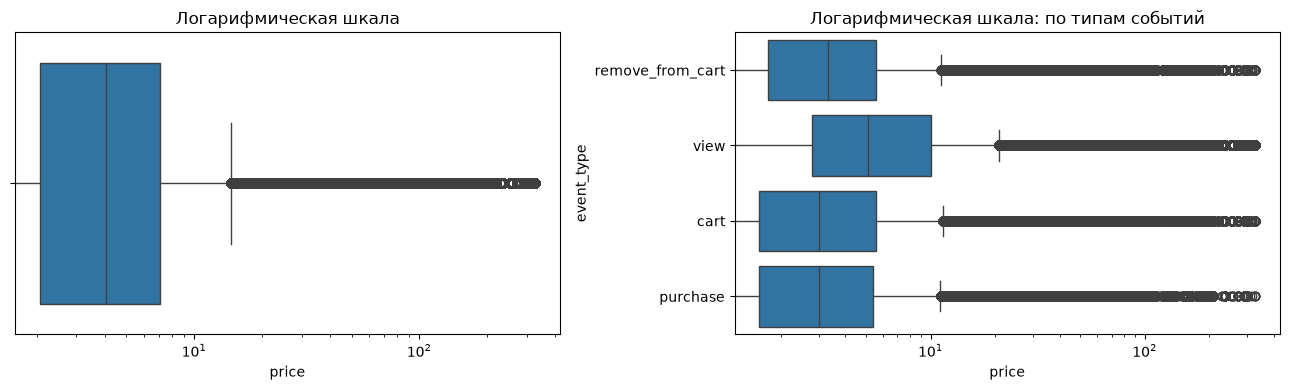

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(x=df['price'], ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_title('Логарифмическая шкала')

sns.boxplot(data=df, x='price', y='event_type', ax=axes[1])
axes[1].set_xscale('log')
axes[1].set_title('Логарифмическая шкала: по типам событий')

plt.tight_layout()
plt.show()

**Промежуточный вывод**
- Строк с отрицательной ценой 0,5%, не будем удалять данные строки, чтобы не сломать воронку. Возможно стоить заменить нелогичные значения на "null" и считать выручку по реальным положительным ценам
- На графиках видно скошенное распределение со сплошным хвостом справа. Будем обрабатывать только отрицательные цены, а все цены больше 0 оставим, так как валюта нам неизвестна

## 6. Временные данные

**Что проверяем**
- Период данных и покрытие файлов

In [14]:
ts = pd.to_datetime(df['event_time']) 

In [15]:
cov = (
    ts
    .groupby(df['source_file'])
    .agg(start='min', end='max', rows='size')
    .sort_values('start')
)

In [16]:
cov['days_with_data'] = (
    ts.dt.normalize()
    .groupby(df['source_file'])
    .nunique()
)
cov['span_days'] = (
    (cov['end'].dt.normalize() 
    - 
    cov['start'].dt.normalize())
    .dt.days + 1
)
cov


,start,end,rows,days_with_data,span_days
source_file,,,,,
2019-Oct.csv,2019-10-01 00:00:00+00:00,2019-10-31 23:59:54+00:00,4102283,31,31
2019-Nov.csv,2019-11-01 00:00:02+00:00,2019-11-30 23:59:58+00:00,4635837,30,30
2019-Dec.csv,2019-12-01 00:00:00+00:00,2019-12-31 23:59:57+00:00,3533286,31,31
2020-Jan.csv,2020-01-01 00:00:00+00:00,2020-01-31 23:59:58+00:00,4264752,31,31
2020-Feb.csv,2020-02-01 00:00:01+00:00,2020-02-29 23:59:59+00:00,4156682,29,29


**Промежуточный вывод**
- Временные данные распределены нормально, каждый месяц содержит реальный период данных

## 7. Решения по итогам EDA

1. Поменять тип данных у поля "event_time"
2. Пропуски оставить
3. Удалить отдельно дубли для расчёта выручки, среднего чека и других связанных метрик
4. Заменить отрицательные значения цен на "null"